# TDW Group Project

# NeuroGrid

## Group Members:
1. Lee Jia Sheng $\;\;\;\;\;\;$ 1211108218
2. Yeo Zing Le   $\;\;\;\;\;\;\;\;\;$ 1211209705  
3. Sek Joo Shan  $\;\;\;\;\;\;$ 1211108716
4. Wong Yan Yee  $\;\;\;\;\;$ 1211111866

# Samsung Mobile Sales Analysis

## Import the Necessary Libraries

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

## Data Wrangling

### Load the dataset

In [172]:
df = pd.read_csv("C:/Users/YEO/OneDrive/Desktop/Degree/Year 2/SEM 3 LONG SEM (2025)/TDW6323-DATA WRANGLING AND VISUAL (DW1,1C)/Project dataset.csv")

Check the shape of dataset

In [173]:
df.shape

(1000, 12)

Check the number of rows

In [174]:
print(f"Number of rows: {df.shape[0]}")

Number of rows: 1000


Check the number of columns

In [175]:
print(f"Number of columns: {df.shape[1]}")

Number of columns: 12


In [176]:
print("\nColumn Names and Data Types:")
print(df.info())


Column Names and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       1000 non-null   int64  
 1   Quarter                    1000 non-null   object 
 2   Product Model              1000 non-null   object 
 3   5G Capability              1000 non-null   object 
 4   Units Sold                 1000 non-null   int64  
 5   Revenue ($)                1000 non-null   float64
 6   Market Share (%)           1000 non-null   float64
 7   Regional 5G Coverage (%)   1000 non-null   float64
 8   5G Subscribers (millions)  1000 non-null   float64
 9   Avg 5G Speed (Mbps)        1000 non-null   float64
 10  Preference for 5G (%)      1000 non-null   float64
 11  Region                     1000 non-null   object 
dtypes: float64(6), int64(2), object(4)
memory usage: 93.9+ KB
None


Check the first few rows of dataset

In [177]:
df.head()

,Year,Quarter,Product Model,5G Capability,Units Sold,Revenue ($),Market Share (%),Regional 5G Coverage (%),5G Subscribers (millions),Avg 5G Speed (Mbps),Preference for 5G (%),Region
0,2019,Q1,Galaxy S10,No,26396,4.212951e+06,1.04,57.36,39.55,293.10,55.87,Asia-Pacific
1,2019,Q1,Galaxy Note10,No,25671,7.240266e+06,2.82,85.80,42.58,67.46,37.26,Latin America
2,2019,Q1,Galaxy S20,No,16573,2.560833e+07,-0.03,47.02,3.78,77.25,84.66,Middle East & Africa
3,2019,Q1,Galaxy Note20,No,7177,2.198442e+07,0.84,25.70,23.41,105.27,40.03,North America
4,2019,Q1,Galaxy S21,No,45633,1.634244e+07,2.36,89.13,44.43,206.17,76.88,Latin America


Check the column statistics

In [178]:
df.describe()

,Year,Units Sold,Revenue ($),Market Share (%),Regional 5G Coverage (%),5G Subscribers (millions),Avg 5G Speed (Mbps),Preference for 5G (%)
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,2021.456000,32842.990000,3.019733e+07,3.723570,66.889720,30.152080,179.225560,67.14291
std,1.700281,16039.770572,1.837941e+07,1.991108,19.254095,14.537781,70.470934,15.75925
min,2019.000000,5309.000000,2.987436e+06,-0.490000,25.340000,-0.890000,50.370000,37.14000
25%,2020.000000,19327.250000,1.460749e+07,2.635000,50.400000,18.412500,120.410000,53.26750
50%,2021.000000,33689.000000,2.801200e+07,3.760000,67.050000,29.915000,177.390000,66.96000
75%,2023.000000,43911.000000,4.180391e+07,5.282500,83.210000,44.360000,238.860000,80.99000
max,2024.000000,64883.000000,8.426494e+07,6.950000,103.920000,54.940000,298.700000,94.84000


Check the missing value

In [179]:
print("\nMissing Values Analysis:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percentage
})
print(missing_data[missing_data['Missing_Count'] > 0])


Missing Values Analysis:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []


There are no missing values

In [180]:
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


Duplicate Rows: 640


Find the unique values in categorical columns

In [181]:
print("\nUnique Values in Categorical Columns:")
categorical_columns = ['Product Model', '5G Capability', 'Region']
for col in categorical_columns:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")
        print(f"  Values: {df[col].unique()}")


Unique Values in Categorical Columns:
Product Model: 15 unique values
  Values: ['Galaxy S10' 'Galaxy Note10' 'Galaxy S20' 'Galaxy Note20' 'Galaxy S21'
 'Galaxy A32 5G' 'Galaxy A52 5G' 'Galaxy A73 5G' 'Galaxy Z Fold2 5G'
 'Galaxy Z Flip3 5G' 'Galaxy S22 5G' 'Galaxy Z Fold3 5G' 'Galaxy A14 5G'
 'Galaxy S23 5G' 'Galaxy Z Flip5 5G']
5G Capability: 2 unique values
  Values: ['No' 'Yes']
Region: 5 unique values
  Values: ['Asia-Pacific' 'Latin America' 'Middle East & Africa' 'North America'
 'Europe']


Check for negative values in numerical columns

In [182]:
numerical_cols = ['Units Sold', 'Revenue ($M)', 'Market Share (%)', 'Regional 5G Subscribers (M)', 'Avg 5G Speed (Mbps)', 'Preference Score']
print("\n1. Negative Values Check:")
for col in numerical_cols:
    if col in df.columns:
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            print(f"  {col}: {negative_count} negative values found")
        else:
            print(f"  {col}: No negative values")


1. Negative Values Check:
  Units Sold: No negative values
  Market Share (%): 49 negative values found
  Avg 5G Speed (Mbps): No negative values


Check for outliers by using IQR method

In [183]:
print("\n2. Outlier Detection:")
for col in numerical_cols:
    if col in df.columns and df[col].dtype in ['int64', 'float64']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"  {col}: {len(outliers)} potential outliers")


2. Outlier Detection:
  Units Sold: 0 potential outliers
  Market Share (%): 0 potential outliers
  Avg 5G Speed (Mbps): 0 potential outliers


Check for data consistency

In [184]:
print("\n3. Categorical Data Consistency:")
for col in categorical_columns:
    if col in df.columns:
        print(f"  {col}: {df[col].value_counts().to_dict()}")


3. Categorical Data Consistency:
  Product Model: {'Galaxy S22 5G': 79, 'Galaxy Note10': 74, 'Galaxy A32 5G': 69, 'Galaxy Z Flip3 5G': 69, 'Galaxy Z Fold3 5G': 69, 'Galaxy A52 5G': 68, 'Galaxy Note20': 67, 'Galaxy S21': 67, 'Galaxy S10': 66, 'Galaxy A73 5G': 66, 'Galaxy Z Fold2 5G': 64, 'Galaxy A14 5G': 62, 'Galaxy Z Flip5 5G': 62, 'Galaxy S20': 60, 'Galaxy S23 5G': 58}
  5G Capability: {'Yes': 666, 'No': 334}
  Region: {'North America': 226, 'Latin America': 205, 'Middle East & Africa': 200, 'Europe': 192, 'Asia-Pacific': 177}


Data Cleaning Process

Since there is no missing values detected, there is no need to handle the missing values

Ensure proper data types

In [185]:
if 'Year' in df.columns:
    df['Year'] = df['Year'].astype(int)
if 'Quarter' in df.columns:
    df['Quarter'] = df['Quarter'].astype(str)
if '5G Capability' in df.columns:
    df['5G Capability'] = df['5G Capability'].map({'Yes': True, 'No': False})

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       1000 non-null   int32  
 1   Quarter                    1000 non-null   object 
 2   Product Model              1000 non-null   object 
 3   5G Capability              1000 non-null   bool   
 4   Units Sold                 1000 non-null   int64  
 5   Revenue ($)                1000 non-null   float64
 6   Market Share (%)           1000 non-null   float64
 7   Regional 5G Coverage (%)   1000 non-null   float64
 8   5G Subscribers (millions)  1000 non-null   float64
 9   Avg 5G Speed (Mbps)        1000 non-null   float64
 10  Preference for 5G (%)      1000 non-null   float64
 11  Region                     1000 non-null   object 
dtypes: bool(1), float64(6), int32(1), int64(1), object(3)
memory usage: 83.1+ KB


Feature Engineering - Create New Features for Analysis

In [187]:
# Create time-based features
if 'Year' in df.columns and 'Quarter' in df.columns:
    df['Year_Quarter'] = df['Year'].astype(str) + '-' + df['Quarter']
    df['Time_Period'] = df['Year_Quarter']

In [188]:
df.head()

,Year,Quarter,Product Model,5G Capability,Units Sold,Revenue ($),Market Share (%),Regional 5G Coverage (%),5G Subscribers (millions),Avg 5G Speed (Mbps),Preference for 5G (%),Region,Year_Quarter,Time_Period
0,2019,Q1,Galaxy S10,False,26396,4.212951e+06,1.04,57.36,39.55,293.10,55.87,Asia-Pacific,2019-Q1,2019-Q1
1,2019,Q1,Galaxy Note10,False,25671,7.240266e+06,2.82,85.80,42.58,67.46,37.26,Latin America,2019-Q1,2019-Q1
2,2019,Q1,Galaxy S20,False,16573,2.560833e+07,-0.03,47.02,3.78,77.25,84.66,Middle East & Africa,2019-Q1,2019-Q1
3,2019,Q1,Galaxy Note20,False,7177,2.198442e+07,0.84,25.70,23.41,105.27,40.03,North America,2019-Q1,2019-Q1
4,2019,Q1,Galaxy S21,False,45633,1.634244e+07,2.36,89.13,44.43,206.17,76.88,Latin America,2019-Q1,2019-Q1


In [189]:
# Create product categories
if 'Product Model' in df.columns:
    df['Product_Line'] = df['Product Model'].str.extract(r'(Galaxy [A-Z]+)')
    df['Product_Series'] = df['Product Model'].str.extract(r'Galaxy ([A-Z]+)')

In [190]:
df.head()

,Year,Quarter,Product Model,5G Capability,Units Sold,Revenue ($),Market Share (%),Regional 5G Coverage (%),5G Subscribers (millions),Avg 5G Speed (Mbps),Preference for 5G (%),Region,Year_Quarter,Time_Period,Product_Line,Product_Series
0,2019,Q1,Galaxy S10,False,26396,4.212951e+06,1.04,57.36,39.55,293.10,55.87,Asia-Pacific,2019-Q1,2019-Q1,Galaxy S,S
1,2019,Q1,Galaxy Note10,False,25671,7.240266e+06,2.82,85.80,42.58,67.46,37.26,Latin America,2019-Q1,2019-Q1,Galaxy N,N
2,2019,Q1,Galaxy S20,False,16573,2.560833e+07,-0.03,47.02,3.78,77.25,84.66,Middle East & Africa,2019-Q1,2019-Q1,Galaxy S,S
3,2019,Q1,Galaxy Note20,False,7177,2.198442e+07,0.84,25.70,23.41,105.27,40.03,North America,2019-Q1,2019-Q1,Galaxy N,N
4,2019,Q1,Galaxy S21,False,45633,1.634244e+07,2.36,89.13,44.43,206.17,76.88,Latin America,2019-Q1,2019-Q1,Galaxy S,S


In [191]:
# Create revenue per unit
if 'Revenue ($M)' in df.columns and 'Units Sold' in df.columns:
    df['Revenue_Per_Unit'] = (df['Revenue ($M)'] * 1000000) / df['Units Sold']

In [192]:
# Create performance categories
if 'Market Share (%)' in df.columns:
    df['Market_Performance'] = pd.cut(df['Market Share (%)'], 
                                     bins=[0, 2, 5, 10, float('inf')],
                                     labels=['Low', 'Medium', 'High', 'Dominant'])

In [193]:
df.head()

,Year,Quarter,Product Model,5G Capability,Units Sold,Revenue ($),Market Share (%),Regional 5G Coverage (%),5G Subscribers (millions),Avg 5G Speed (Mbps),Preference for 5G (%),Region,Year_Quarter,Time_Period,Product_Line,Product_Series,Market_Performance
0,2019,Q1,Galaxy S10,False,26396,4.212951e+06,1.04,57.36,39.55,293.10,55.87,Asia-Pacific,2019-Q1,2019-Q1,Galaxy S,S,Low
1,2019,Q1,Galaxy Note10,False,25671,7.240266e+06,2.82,85.80,42.58,67.46,37.26,Latin America,2019-Q1,2019-Q1,Galaxy N,N,Medium
2,2019,Q1,Galaxy S20,False,16573,2.560833e+07,-0.03,47.02,3.78,77.25,84.66,Middle East & Africa,2019-Q1,2019-Q1,Galaxy S,S,NaN
3,2019,Q1,Galaxy Note20,False,7177,2.198442e+07,0.84,25.70,23.41,105.27,40.03,North America,2019-Q1,2019-Q1,Galaxy N,N,Low
4,2019,Q1,Galaxy S21,False,45633,1.634244e+07,2.36,89.13,44.43,206.17,76.88,Latin America,2019-Q1,2019-Q1,Galaxy S,S,Medium


In [194]:
cleaning_steps = []

In [195]:
initial_rows = len(df)
df.drop_duplicates(inplace=True)
final_rows = len(df)
if initial_rows != final_rows:
    cleaning_steps.append(f"Removed {initial_rows - final_rows} duplicate rows")

In [196]:
cleaning_steps

['Removed 640 duplicate rows']

In [197]:
df.shape

(360, 17)

In [198]:
df.head()

,Year,Quarter,Product Model,5G Capability,Units Sold,Revenue ($),Market Share (%),Regional 5G Coverage (%),5G Subscribers (millions),Avg 5G Speed (Mbps),Preference for 5G (%),Region,Year_Quarter,Time_Period,Product_Line,Product_Series,Market_Performance
0,2019,Q1,Galaxy S10,False,26396,4.212951e+06,1.04,57.36,39.55,293.10,55.87,Asia-Pacific,2019-Q1,2019-Q1,Galaxy S,S,Low
1,2019,Q1,Galaxy Note10,False,25671,7.240266e+06,2.82,85.80,42.58,67.46,37.26,Latin America,2019-Q1,2019-Q1,Galaxy N,N,Medium
2,2019,Q1,Galaxy S20,False,16573,2.560833e+07,-0.03,47.02,3.78,77.25,84.66,Middle East & Africa,2019-Q1,2019-Q1,Galaxy S,S,NaN
3,2019,Q1,Galaxy Note20,False,7177,2.198442e+07,0.84,25.70,23.41,105.27,40.03,North America,2019-Q1,2019-Q1,Galaxy N,N,Low
4,2019,Q1,Galaxy S21,False,45633,1.634244e+07,2.36,89.13,44.43,206.17,76.88,Latin America,2019-Q1,2019-Q1,Galaxy S,S,Medium


In [199]:
print(f"\nFinal Dataset Shape: {df.shape}")
print("\nNew columns created:")
new_columns = ['Year_Quarter', 'Product_Line', 'Product_Series', 'Revenue_Per_Unit', 'Market_Performance', '5G_Adoption_Level']
for col in new_columns:
    if col in df.columns:
        print(f"  - {col}")


Final Dataset Shape: (360, 17)

New columns created:
  - Year_Quarter
  - Product_Line
  - Product_Series
  - Market_Performance


Compute and analyze summary statistics for numerical and categorical variables (e.g.,mean, median, standard deviation, mode).

In [200]:
# Summary Statistics for Numerical variables summary
numeric_df = df.select_dtypes(include=[np.number])
num_summary = numeric_df.describe().T
num_summary['median'] = numeric_df.median()
num_summary['mode'] = numeric_df.mode().iloc[0]
num_summary = num_summary[['mean', 'median', 'std', 'mode', 'min', 'max']]
print("Numerical Variables Summary:")
display(num_summary)

Numerical Variables Summary:


,mean,median,std,mode,min,max
Year,2.021500e+03,2.021500e+03,1.710202e+00,2019.000,2019.000,2024.00
Units Sold,3.264622e+04,3.301800e+04,1.631343e+04,7177.000,5309.000,64883.00
Revenue ($),2.990730e+07,2.784645e+07,1.848561e+07,2987436.384,2987436.384,84264943.84
Market Share (%),3.716167e+00,3.710000e+00,1.985063e+00,0.340,-0.490,6.95
Regional 5G Coverage (%),6.688519e+01,6.700000e+01,1.943100e+01,74.460,25.340,103.92
5G Subscribers (millions),3.013719e+01,2.991500e+01,1.455124e+01,7.360,-0.890,54.94
Avg 5G Speed (Mbps),1.799729e+02,1.787350e+02,7.065762e+01,93.600,50.370,298.70
Preference for 5G (%),6.729178e+01,6.747500e+01,1.559070e+01,45.430,37.140,94.84


In [201]:
#Summary Categorical variables summary
cat_df = df.select_dtypes(include=['object', 'category'])
print("\nCategorical Variables Frequencies:")
for col in cat_df.columns:
    print(f"\n– {col} value counts:")
    print(cat_df[col].value_counts().to_frame(name='count'))


Categorical Variables Frequencies:

– Quarter value counts:
         count
Quarter       
Q1          90
Q2          90
Q3          90
Q4          90

– Product Model value counts:
                   count
Product Model           
Galaxy S10            24
Galaxy Note10         24
Galaxy S20            24
Galaxy Note20         24
Galaxy S21            24
Galaxy A32 5G         24
Galaxy A52 5G         24
Galaxy A73 5G         24
Galaxy Z Fold2 5G     24
Galaxy Z Flip3 5G     24
Galaxy S22 5G         24
Galaxy Z Fold3 5G     24
Galaxy A14 5G         24
Galaxy S23 5G         24
Galaxy Z Flip5 5G     24

– Region value counts:
                      count
Region                     
North America            81
Latin America            72
Europe                   71
Middle East & Africa     70
Asia-Pacific             66

– Year_Quarter value counts:
              count
Year_Quarter       
2019-Q1          15
2019-Q2          15
2024-Q3          15
2024-Q2          15
2024-Q1          15
202

In [202]:
print(numeric_df)

     Year  Units Sold   Revenue ($)  Market Share (%)  \
0    2019       26396  4.212951e+06              1.04   
1    2019       25671  7.240266e+06              2.82   
2    2019       16573  2.560833e+07             -0.03   
3    2019        7177  2.198442e+07              0.84   
4    2019       45633  1.634244e+07              2.36   
..    ...         ...           ...               ...   
355  2024       28368  1.763926e+07              5.79   
356  2024       31313  3.361639e+07              6.70   
357  2024       10175  3.158442e+07              6.39   
358  2024       27459  4.829709e+07              2.65   
359  2024       23576  7.378715e+06              4.94   

     Regional 5G Coverage (%)  5G Subscribers (millions)  Avg 5G Speed (Mbps)  \
0                       57.36                      39.55               293.10   
1                       85.80                      42.58                67.46   
2                       47.02                       3.78                

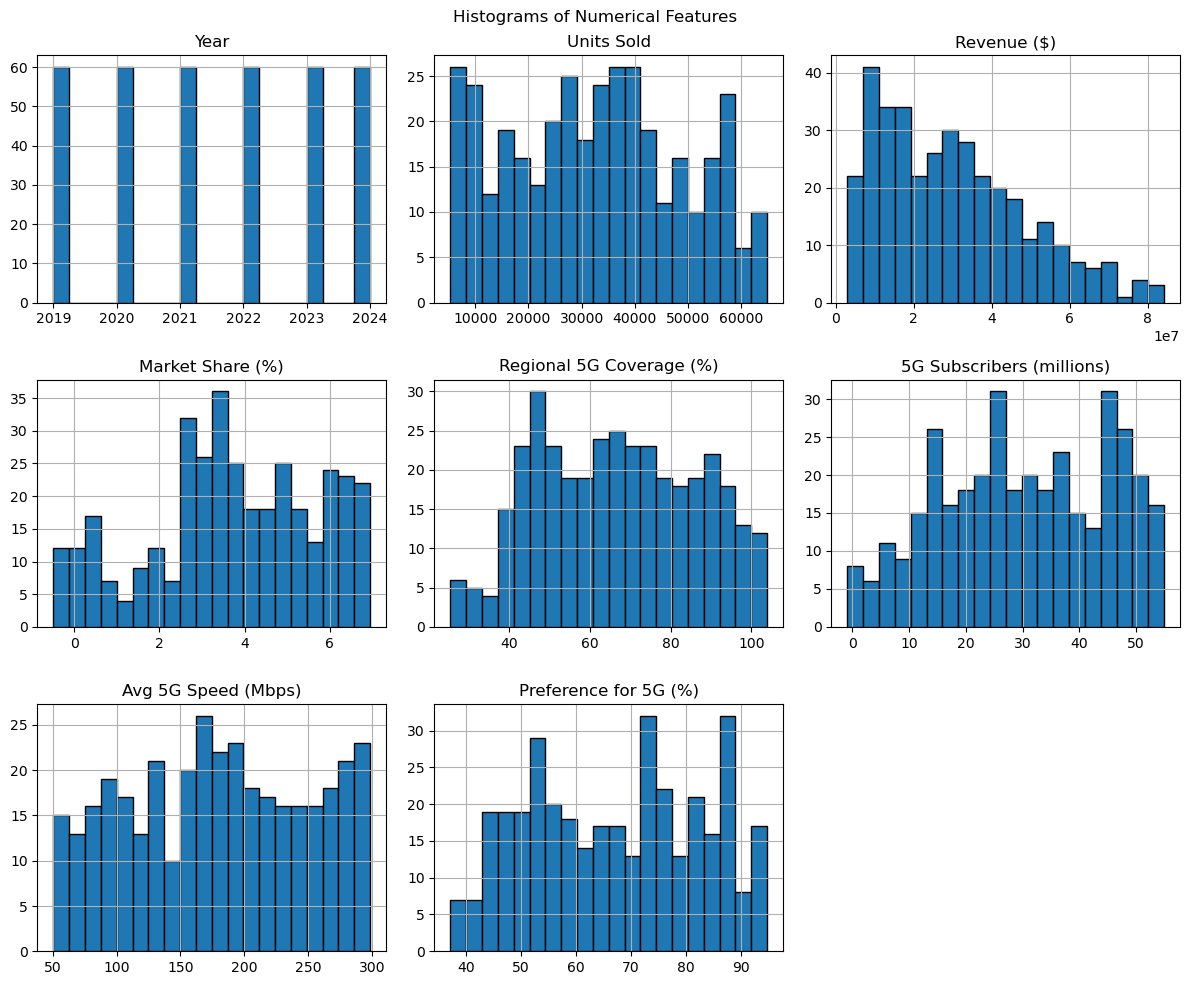

In [203]:
#Identify patterns, trends, and anomalies in the data.

# Histograms for each numeric feature
numeric_df.hist(bins=20, figsize=(12,10), edgecolor='black')
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()

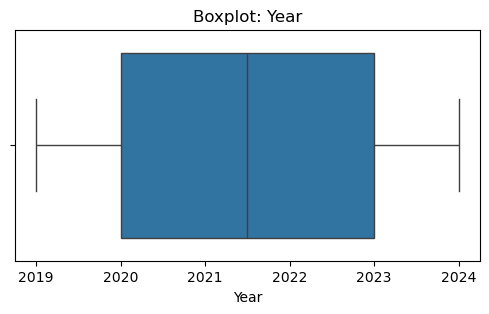

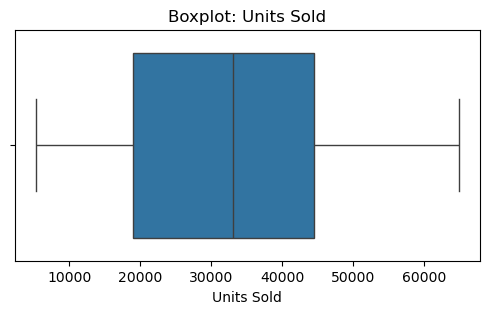

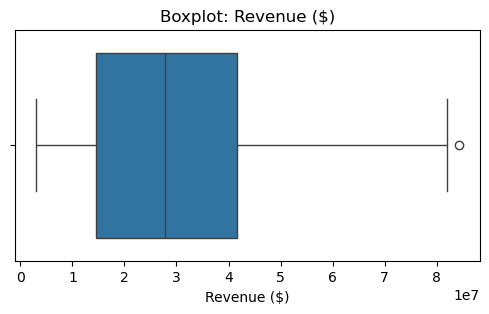

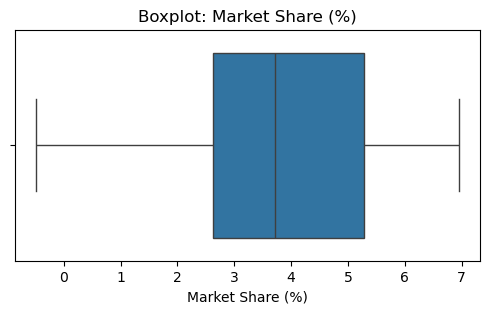

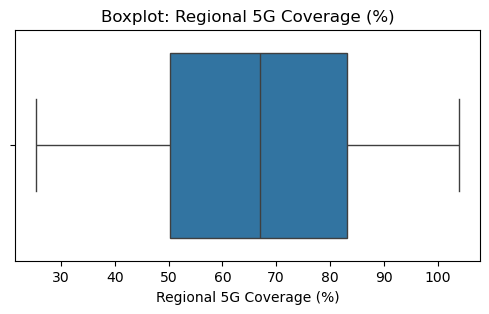

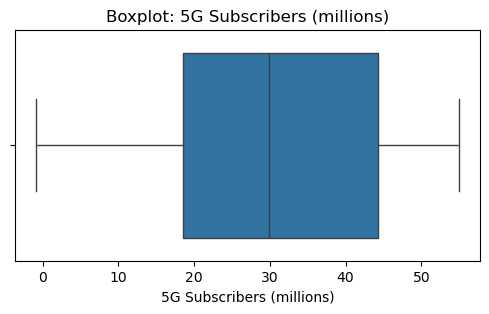

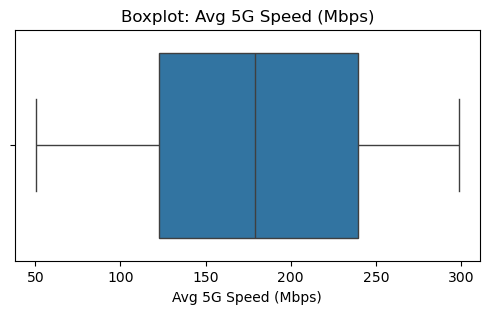

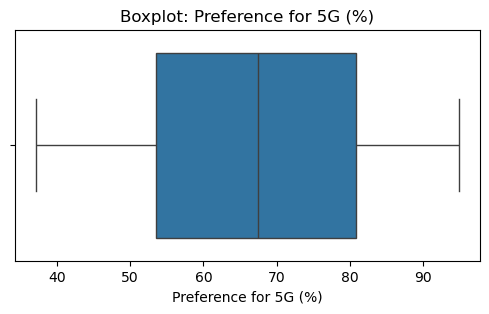

In [204]:
#one plot per feature,
for col in numeric_df.columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=numeric_df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()



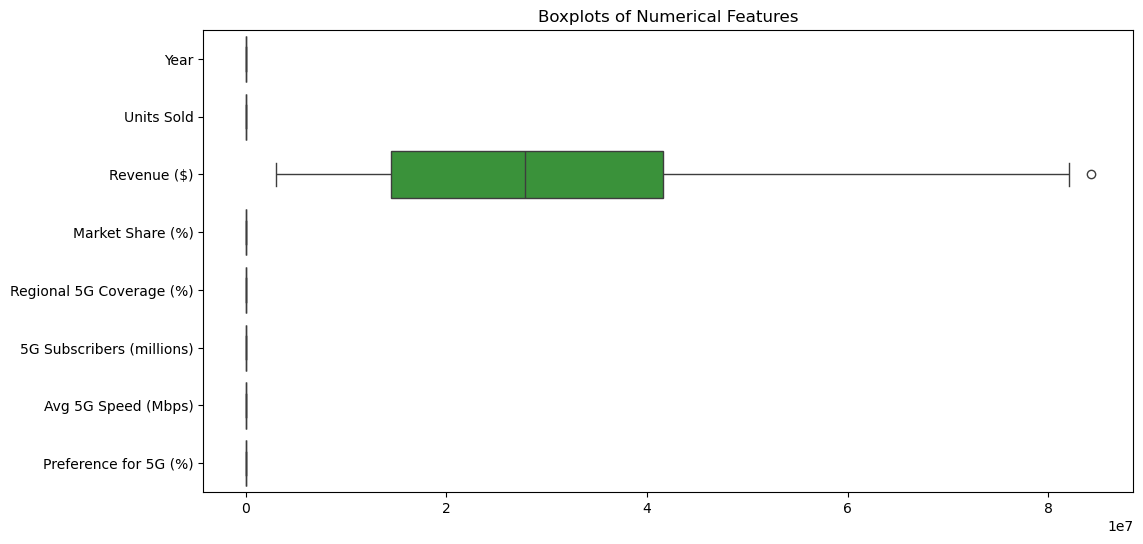

In [205]:
# Boxplots to spot outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=numeric_df, orient='h')
plt.title('Boxplots of Numerical Features')
plt.show()

In [206]:
# Example: Identify outliers via Z‑score
from scipy import stats
z_scores = np.abs(stats.zscore(numeric_df, nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)
print(z_scores)
print(f"Detected {outlier_mask.sum()} potential outlier rows (|z| > 3).")

        Year  Units Sold  Revenue ($)  Market Share (%)  \
0    1.46385    0.383667     1.391899          1.350029   
1    1.46385    0.428170     1.227905          0.452083   
2    1.46385    0.986647     0.232881          1.889805   
3    1.46385    1.563415     0.429194          1.450921   
4    1.46385    0.797187     0.734828          0.684137   
..       ...         ...          ...               ...   
355  1.46385    0.262616     0.664577          1.046173   
356  1.46385    0.081839     0.200927          1.505235   
357  1.46385    1.379385     0.090852          1.348852   
358  1.46385    0.318415     0.996201          0.537842   
359  1.46385    0.556771     1.220405          0.617379   

     Regional 5G Coverage (%)  5G Subscribers (millions)  Avg 5G Speed (Mbps)  \
0                    0.490888                   0.647773             1.603288   
1                    0.974789                   0.856293             1.594584   
2                    1.023769                   

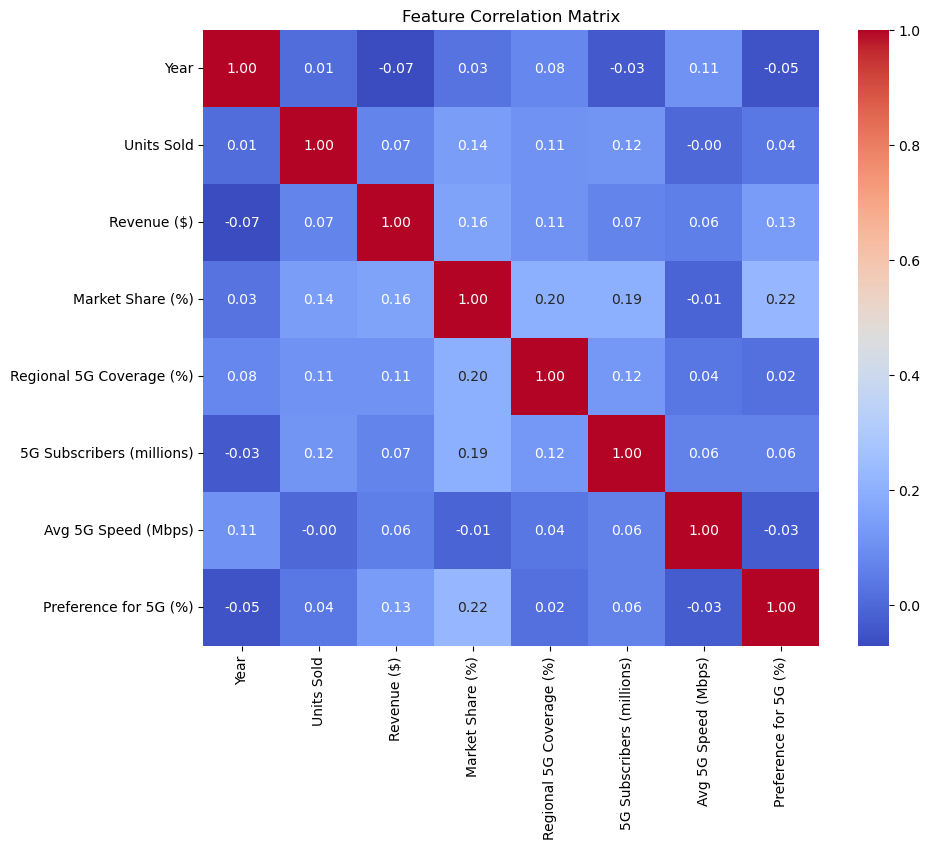

In [207]:
#Apply correlation analysis to detect relationships between variables.

# Compute Pearson correlation matrix
corr = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.show()

In [208]:
# Flatten and sort correlations for inspection
corr_pairs = (
    corr.abs()
    .unstack()
    .reset_index()
    .rename(columns={'level_0':'feature1','level_1':'feature2', 0:'abs_corr'})
)

In [209]:
# Remove self‑correlations and duplicates
corr_pairs = corr_pairs[corr_pairs['feature1'] != corr_pairs['feature2']]
corr_pairs = corr_pairs.drop_duplicates(subset=['abs_corr'])
high_corr = corr_pairs.sort_values('abs_corr', ascending=False).head(10)
print("Top 10 strongest correlations:")
display(high_corr)



Top 10 strongest correlations:


,feature1,feature2,abs_corr
31,Market Share (%),Preference for 5G (%),0.224371
28,Market Share (%),Regional 5G Coverage (%),0.196834
29,Market Share (%),5G Subscribers (millions),0.194367
19,Revenue ($),Market Share (%),0.156542
11,Units Sold,Market Share (%),0.138855
23,Revenue ($),Preference for 5G (%),0.134687
37,Regional 5G Coverage (%),5G Subscribers (millions),0.124859
13,Units Sold,5G Subscribers (millions),0.116702
6,Year,Avg 5G Speed (Mbps),0.111984
20,Revenue ($),Regional 5G Coverage (%),0.111166


#Explain how the analysis contributes to understanding the business problem and making data-driven decisions.

- Risk Management: Detection of outliers can help us to mark implausible values (e.g. sensor errors) and remove data quality issues.
- Feature Engineering: Understanding which variables co-move helps us simplify models by combining or removing features.
- Decision Support: Stakeholders can be supplied with a single glance overview of data health and distribution via clear statistical summaries.
- Predictive Modeling: When the feature set is well understood, without redundancy and with engineered insights, the resulting models are more robust and interpretable and       directly useful in our forecasting or diagnostic goals.